Importing important libraries including numpy for numerical operations, pandas for data manipulation, matplotlib, seaborn for enhanced plottig, etc.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import inv
import statsmodels.api as sm
from scipy.stats import norm

from scipy.stats import pearsonr

Importing dataset

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the CSV files
X = pd.read_csv('/content/drive/MyDrive/data/Coursework_Data/X.csv')
y = pd.read_csv('/content/drive/MyDrive/data/Coursework_Data/y.csv')
time = pd.read_csv('/content/drive/MyDrive/data/Coursework_Data/time.csv')

In [26]:
# Ensure correct data types
X.columns = ["x1", "x2"]
y.columns = ["y"]
time.columns = ["time"]

X["x1"] = X["x1"].astype(float)
X["x2"] = X["x2"].astype(int)
y["y"] = y["y"].astype(float)
time["time"] = time["time"].astype(float)

#  Combine all into one dataframe
df = pd.concat([time, X, y], axis=1)

# Task 1: Preliminary Data Analysis

In [27]:
X.head()


,x1,x2
0,-1.383423,0
1,0.491178,0
2,-0.528827,0
3,-0.359455,0
4,0.173340,0


In [28]:
y.head()


,y
0,10.677616
1,18.885513
2,11.246081
3,9.364583
4,13.434298


In [31]:
time.head()

,time
0,0.1
1,0.2
2,0.3
3,0.4
4,0.5


In [32]:
# Drop header-like row if present
if not pd.api.types.is_numeric_dtype(time["time"]):
    X = X[1:].reset_index(drop=True)
    y = y[1:].reset_index(drop=True)
    time = time[1:].reset_index(drop=True)

In [33]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Shape of time:", time.shape)

Shape of X: (200, 2)
Shape of y: (200, 1)
Shape of time: (200, 1)


### 1.Time Series Plots

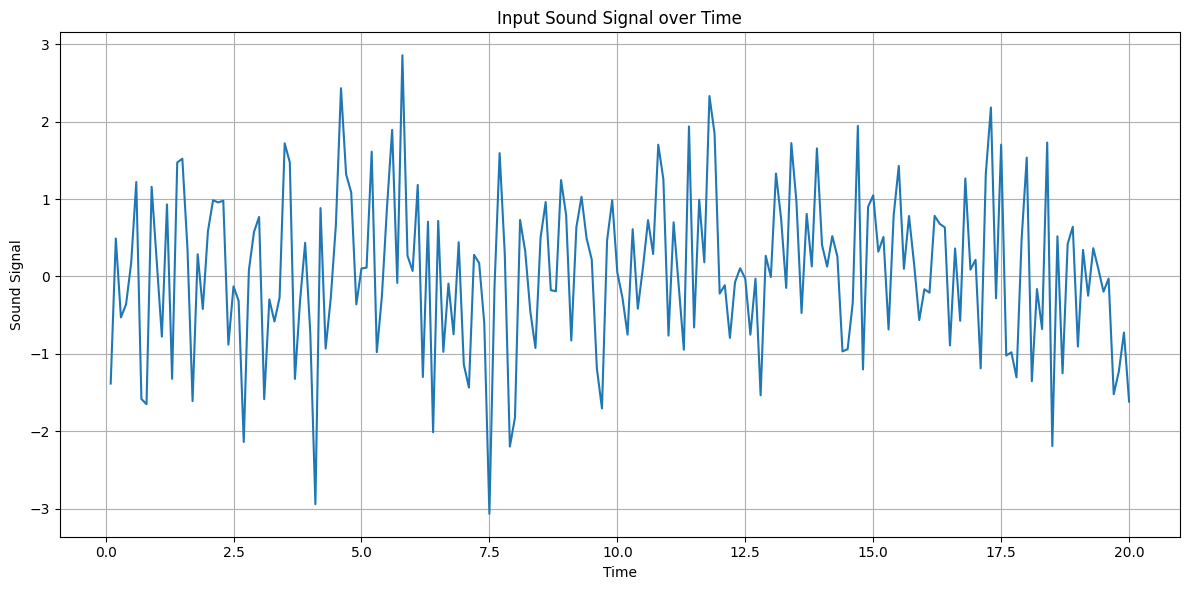

In [34]:
# 1. Time Series Plots
plt.figure(figsize=(12, 6))
plt.plot(time['time'], X['x1'], label='Input Sound (x1)')
plt.xlabel('Time')
plt.ylabel('Sound Signal')
plt.title('Input Sound Signal over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

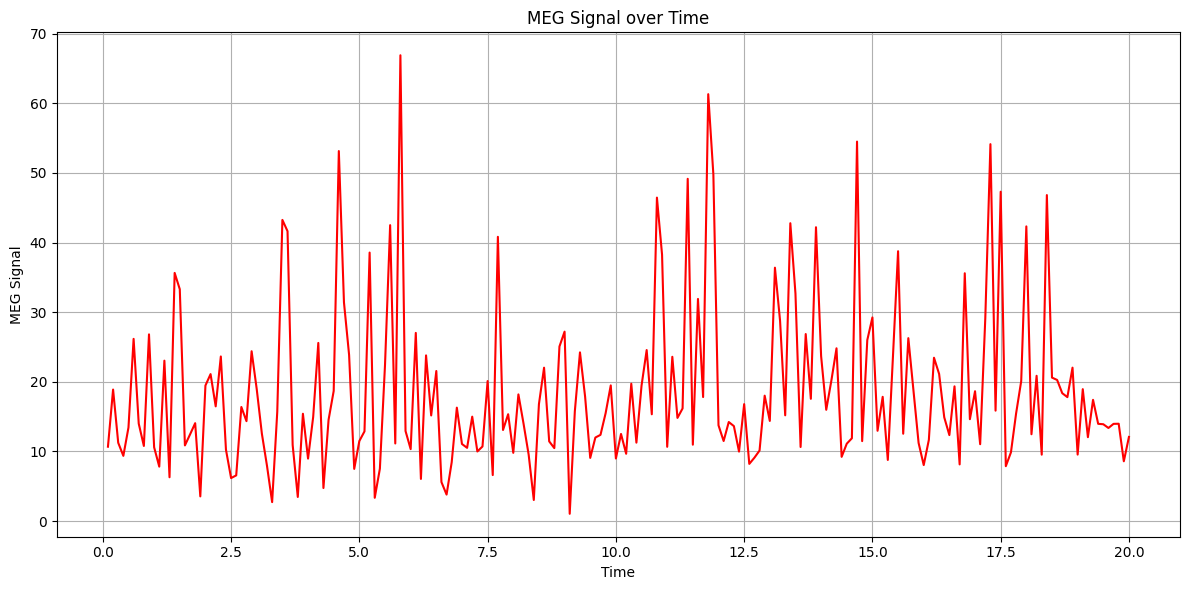

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(time['time'], y['y'], label='MEG Signal (y)', color='red')
plt.xlabel('Time')
plt.ylabel('MEG Signal')
plt.title('MEG Signal over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

### 2.Histograms (Distributions of Inputs and Output)

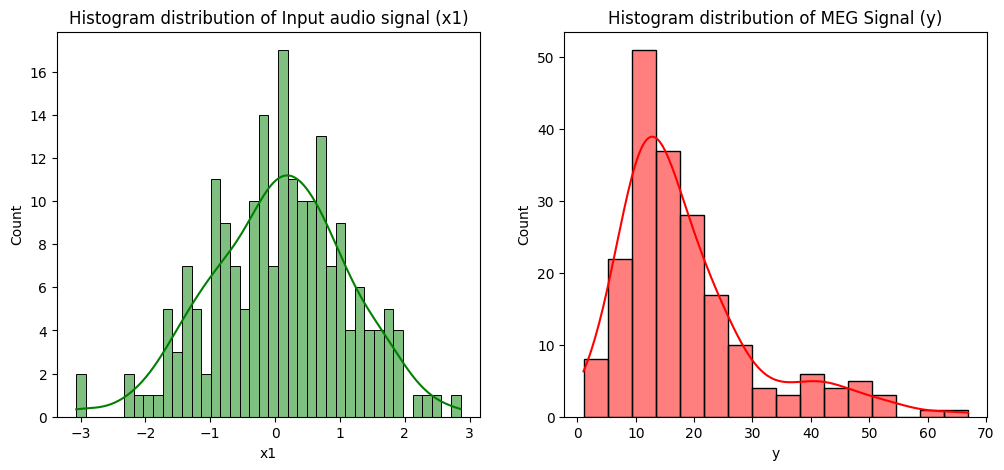


Descriptive Statistics for x1:
 count    200.000000
mean       0.065065
std        1.042515
min       -3.066635
25%       -0.680266
50%        0.109326
75%        0.754653
max        2.858984
Name: x1, dtype: float64

Descriptive Statistics for y:
 count    200.000000
mean      18.604033
std       11.879710
min        1.041340
25%       10.843684
50%       15.079138
75%       23.141470
max       66.900218
Name: y, dtype: float64


In [24]:
# 2. Histograms of distributions of Inputs and Output
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
sns.histplot(X['x1'], kde=True, bins = 40, color = "green")
plt.title('Histogram distribution of Input audio signal (x1)')

plt.subplot(1, 2, 2)  # 1 row, 2 columns, second plot
sns.histplot(y['y'], kde=True, color='red')
plt.title('Histogram distribution of MEG Signal (y)')

plt.show()

print("\nDescriptive Statistics for x1:\n", X['x1'].describe())
print("\nDescriptive Statistics for y:\n", y['y'].describe())



### 3. Correlation & Scatter Plot


Pearson correlation between x1 and y: r = 0.765, p = 9.403e-40

Correlation Matrix:
           x1         y
x1  1.000000  0.765365
y   0.765365  1.000000


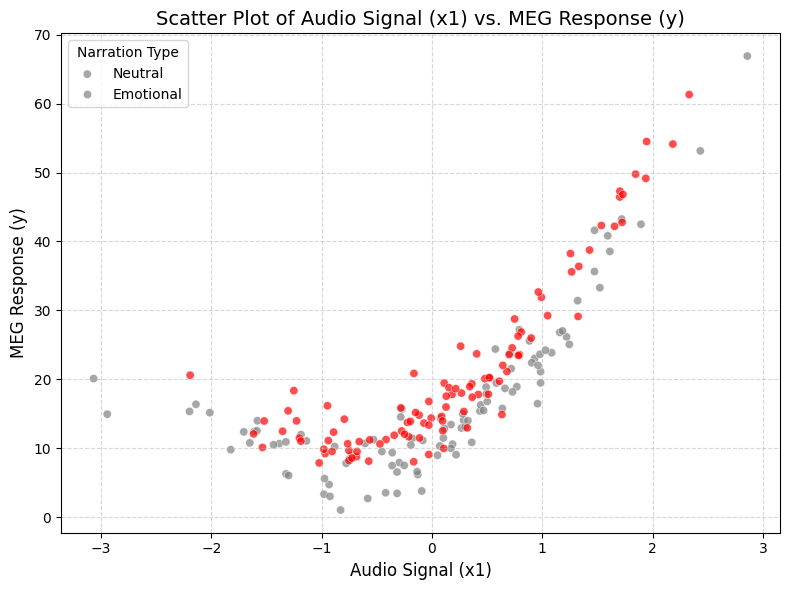


Correlation (Neutral): 0.701
Correlation (Emotional): 0.850


In [38]:
# Calculate Pearson Correlation
corr_coef, p_value = pearsonr(X['x1'], y['y'])  # Use original DataFrames
print(f"\nPearson correlation between x1 and y: r = {corr_coef:.3f}, p = {p_value:.3e}")

# Alternative: Correlation Matrix (for completeness)
corr_matrix = pd.concat([X['x1'], y['y']], axis=1).corr()
print("\nCorrelation Matrix:\n", corr_matrix)


# Scatter Plot with different color for Narration Type
plt.figure(figsize=(8, 6))  # Larger figure for better readability
sns.scatterplot(
    x=X['x1'], y=y['y'],  # Use original DataFrames
    hue=X['x2'],  # Hue based on x2
    palette={0: "gray", 1: "red"},
    alpha=0.7,  # Add some transparency
)
plt.title("Scatter Plot of Audio Signal (x1) vs. MEG Response (y)", fontsize=14) # More specific title
plt.xlabel("Audio Signal (x1)", fontsize=12)
plt.ylabel("MEG Response (y)", fontsize=12)
plt.legend(title="Narration Type", labels=["Neutral", "Emotional"])
plt.grid(True, linestyle='--', alpha=0.5)  # Add a subtle grid
plt.tight_layout()
plt.show()


# Additional Analysis (if needed for your report)
#  Calculate correlation SEPARATELY for neutral and emotional
corr_neutral, _ = pearsonr(X['x1'][X['x2'] == 0], y['y'][X['x2'] == 0])
corr_emotional, _ = pearsonr(X['x1'][X['x2'] == 1], y['y'][X['x2'] == 1])

print(f"\nCorrelation (Neutral): {corr_neutral:.3f}")
print(f"Correlation (Emotional): {corr_emotional:.3f}")

 ### 4. Boxplots of MEG (y) by Narration Type

<ipython-input-41-0fbfa38e7f5a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(



Descriptive Statistics (Neutral):
|       | y       |
|:------|:--------|
| count | 100     |
| mean  | 16.5842 |
| std   | 11.168  |
| min   | 1.04134 |
| 25%   | 9.94553 |
| 50%   | 13.9923 |
| 75%   | 21.216  |
| max   | 66.9002 |

Descriptive Statistics (Emotional):
|       | y       |
|:------|:--------|
| count | 100     |
| mean  | 20.6239 |
| std   | 12.2765 |
| min   | 7.87727 |
| 25%   | 12.0066 |
| 50%   | 16.4819 |
| 75%   | 23.913  |
| max   | 61.3105 |


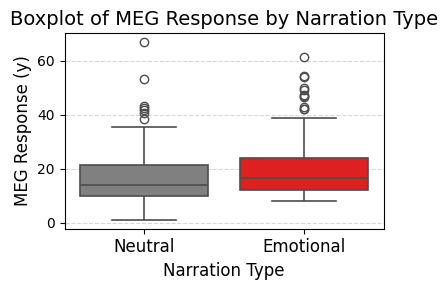

In [41]:
plt.figure(figsize=(4, 3))  # Larger figure
sns.boxplot(
    x=X["x2"],  # Use X DataFrame
    y=y["y"],  # Use y DataFrame
    palette=["gray", "red"],
    linewidth=1.2,  # Thicker lines for clarity
)
plt.xticks([0, 1], ["Neutral", "Emotional"], fontsize=12)  # Larger x-tick labels
plt.title("Boxplot of MEG Response by Narration Type", fontsize=14)
plt.xlabel("Narration Type", fontsize=12)
plt.ylabel("MEG Response (y)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)  # Grid only on y-axis
plt.tight_layout()

# Calculate and print descriptive statistics for each group (for report)
print("\nDescriptive Statistics (Neutral):")
print(y["y"][X["x2"] == 0].describe().to_markdown(numalign="left", stralign="left"))

print("\nDescriptive Statistics (Emotional):")
print(y["y"][X["x2"] == 1].describe().to_markdown(numalign="left", stralign="left"))

plt.show()

5. Linear Fit Overlay for Visual Inspection

/usr/local/lib/python3.11/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


<Figure size 400x300 with 0 Axes>

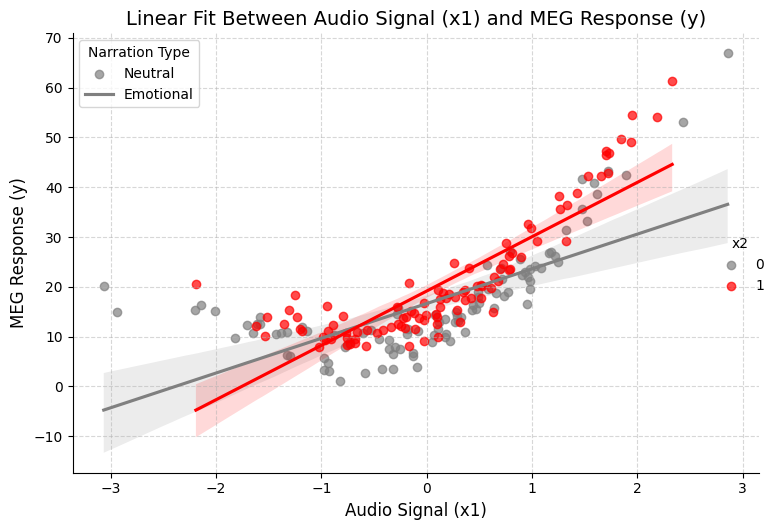

In [47]:
plt.figure(figsize=(4, 3))
sns.lmplot(
    x="x1",
    y="y",
    hue="x2",
    data=pd.concat([X, y], axis=1),  # Used X and y directly
    palette={0: "gray", 1: "red"},
    height=6,
    aspect=1.2,
    scatter_kws={'alpha': 0.7},

    legend_out=True,
)
plt.title("Linear Fit Between Audio Signal (x1) and MEG Response (y)", fontsize=14)
plt.xlabel("Audio Signal (x1)", fontsize=12)
plt.ylabel("MEG Response (y)", fontsize=12)
plt.legend(title="Narration Type", labels=["Neutral", "Emotional"])
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Task 2: Regression Modeling

In this task, the motive is to fit five different regression models to your data and then select the "best" one based on certain criteria.

In [48]:
# Extract data as numpy arrays for matrix operations
x1 = X['x1'].values
x2 = X['x2'].values
y = y['y'].values
sample_count = len(y)

In [49]:
# Defining the polynomial regression models by different different names
def model_1(x1, x2):
    return np.column_stack([x1**3, x1**5, x2, np.ones(len(x1))])

def model_2(x1, x2):
    return np.column_stack([x1, x2, np.ones(len(x1))])

def model_3(x1, x2):
    return np.column_stack([x1, x1**2, x1**4, x2, np.ones(len(x1))])

def model_4(x1, x2):
    return np.column_stack([x1, x1**2, x1**3, x1**5, x2, np.ones(len(x1))])

def model_5(x1, x2):
    return np.column_stack([x1, x1**3, x1**4, x2, np.ones(len(x1))])

models = [model_1, model_2, model_3, model_4, model_5]
model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5']
results = {}                        # For storing results in dictionary format


In [53]:
""" # 2.1 Parameter Estimation (Least Squares)
print(" Model 1 ")
design_matrix1 = models[0](x1, x2)
coefficients1 = inv(design_matrix1.T @ design_matrix1) @ design_matrix1.T @ y
results[model_names[0]] = {'theta': coefficients1}
print("Theta:", coefficients1)

predictions1 = design_matrix1 @ coefficients1
residuals1 = y - predictions1
rss1 = np.sum(residuals1**2)
results[model_names[0]]['rss'] = rss1
print("RSS:", rss1)

variance1 = rss1 / (sample_count - 1)
log_likelihood1 = -(sample_count / 2) * np.log(2 * np.pi) - (sample_count / 2) * np.log(variance1) - (1 / (2 * variance1)) * rss1
results[model_names[0]]['log_likelihood'] = log_likelihood1
print("Log-Likelihood:", log_likelihood1)"""


 Model 1 
Theta: [ 5.17127282 -0.53732529  2.20201791 16.93575071]
RSS: 11825.421352951202
Log-Likelihood: -691.7579086795048


In [54]:
"""# 2.2 Residual Sum of Squares (RSS)
print(" Model 2 ")
design_matrix2 = models[1](x1, x2)
coefficients2 = inv(design_matrix2.T @ design_matrix2) @ design_matrix2.T @ y
results[model_names[1]] = {'theta': coefficients2}
print("Theta:", coefficients2)

predictions2 = design_matrix2 @ coefficients2
residuals2 = y - predictions2
rss2 = np.sum(residuals2**2)
results[model_names[1]]['rss'] = rss2
print("RSS:", rss2)

variance2 = rss2 / (sample_count - 1)
log_likelihood2 = -(sample_count / 2) * np.log(2 * np.pi) - (sample_count / 2) * np.log(variance2) - (1 / (2 * variance2)) * rss2
results[model_names[1]]['log_likelihood'] = log_likelihood2
print("Log-Likelihood:", log_likelihood2)
"""

 Model 2 
Theta: [ 8.62910686  2.81398685 16.63559026]
RSS: 11238.949638549428
Log-Likelihood: -686.6712912238319


In [55]:
"""# 2.3 Log-Likelihood
print(" Model 3 ")
design_matrix3 = models[2](x1, x2)
coefficients3 = inv(design_matrix3.T @ design_matrix3) @ design_matrix3.T @ y
results[model_names[2]] = {'theta': coefficients3}
print("Theta:", coefficients3)

predictions3 = design_matrix3 @ coefficients3
residuals3 = y - predictions3
rss3 = np.sum(residuals3**2)
results[model_names[2]]['rss'] = rss3
print("RSS:", rss3)

variance3 = rss3 / (sample_count - 1)
log_likelihood3 = -(sample_count / 2) * np.log(2 * np.pi) - (sample_count / 2) * np.log(variance3) - (1 / (2 * variance3)) * rss3
results[model_names[2]]['log_likelihood'] = log_likelihood3
print("Log-Likelihood:", log_likelihood3)"""

 Model 3 
Theta: [ 8.55216135  6.24691708 -0.28296309  4.15988326 10.17369609]
RSS: 1636.16760677224
Log-Likelihood: -493.9684202727278


In [64]:
# 2.1 Parameter Estimation (Least Squares)
for i, model in enumerate(models):
    print(f"{model_names[i]} ")


    X_model = model(x1, x2)
    theta = inv(X_model.T @ X_model) @ X_model.T @ y
    results[model_names[i]] = {'theta': theta}
    print("Theta:", theta)

Model 1 
Theta: [ 5.17127282 -0.53732529  2.20201791 16.93575071]
Model 2 
Theta: [ 8.62910686  2.81398685 16.63559026]
Model 3 
Theta: [ 8.55216135  6.24691708 -0.28296309  4.15988326 10.17369609]
Model 4 
Theta: [ 9.35397322  4.64696205 -0.57792162  0.07479626  4.34321644 10.85328261]
Model 5 
Theta: [ 8.07945806  0.31445012  0.55920502  3.96814553 14.13172537]


In [65]:
# 2.2 Residual Sum of Squares (RSS)

for i, model in enumerate(models):
    print(f" {model_names[i]} ")

    X_model = model(x1, x2)  # Calculate X_model here for each model
    theta = inv(X_model.T @ X_model) @ X_model.T @ y  # Calculate theta here

    y_predicted = X_model @ theta
    residuals = y - y_predicted
    rss = np.sum(residuals**2)
    results[model_names[i]]['rss'] = rss
    print("RSS:", rss)

 Model 1 
RSS: 11825.421352951202
 Model 2 
RSS: 11238.949638549428
 Model 3 
RSS: 1636.16760677224
 Model 4 
RSS: 1902.0628559965812
 Model 5 
RSS: 4928.31206100396


In [67]:
# 2.3 Log-Likelihood
for i, model in enumerate(models):
    print(f" {model_names[i]} ")

    X_model = model(x1, x2)
    theta = inv(X_model.T @ X_model) @ X_model.T @ y

    # Get RSS from the 'results' dictionary
    rss = results[model_names[i]]['rss']

    # Calculate variance and log-likelihood
    variance = rss / (sample_count - len(theta))
    log_likelihood = -(sample_count / 2) * np.log(2 * np.pi * variance) - (rss / (2 * variance))

    # Store log-likelihood
    results[model_names[i]]['log_likelihood'] = log_likelihood

    print("Log-Likelihood:", log_likelihood)

 Model 1 
Log-Likelihood: -691.7769252289023
 Model 2 
Log-Likelihood: -686.6814008224821
 Model 3 
Log-Likelihood: -493.9989468888024
 Model 4 
Log-Likelihood: -509.07131972221174
 Model 5 
Log-Likelihood: -604.2629335121433


In [68]:
# 2.4 AIC and BIC
for i, model in enumerate(models):
    print(f" {model_names[i]} ")

    # Get necessary values from the results dictionary
    log_likelihood = results[model_names[i]]['log_likelihood']
    num_params = len(results[model_names[i]]['theta'])  # Number of parameters

    # Calculate AIC and BIC
    aic = -2 * log_likelihood + 2 * num_params
    bic = -2 * log_likelihood + num_params * np.log(sample_count)

    # Store AIC and BIC in the results dictionary
    results[model_names[i]]['aic'] = aic
    results[model_names[i]]['bic'] = bic

    print("AIC:", aic)
    print("BIC:", bic)

 Model 1 
AIC: 1391.5538504578046
BIC: 1404.7471199239967
 Model 2 
AIC: 1379.3628016449643
BIC: 1389.2577537446084
 Model 3 
AIC: 997.9978937776048
BIC: 1014.4894806103449
 Model 4 
AIC: 1030.1426394444234
BIC: 1049.9325436437116
 Model 5 
AIC: 1218.5258670242865
BIC: 1235.0174538570268


 Model 1 


<Figure size 600x600 with 0 Axes>

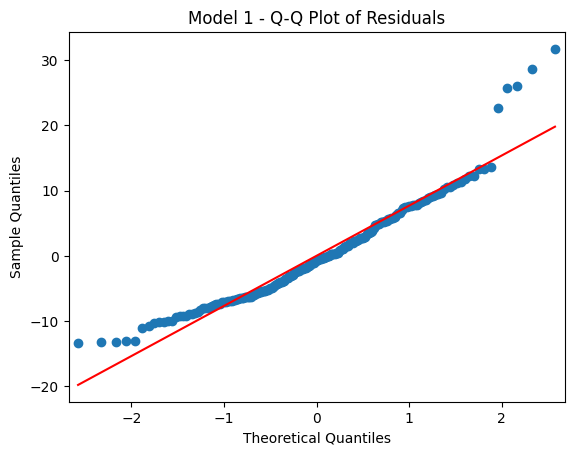

 Model 2 


<Figure size 600x600 with 0 Axes>

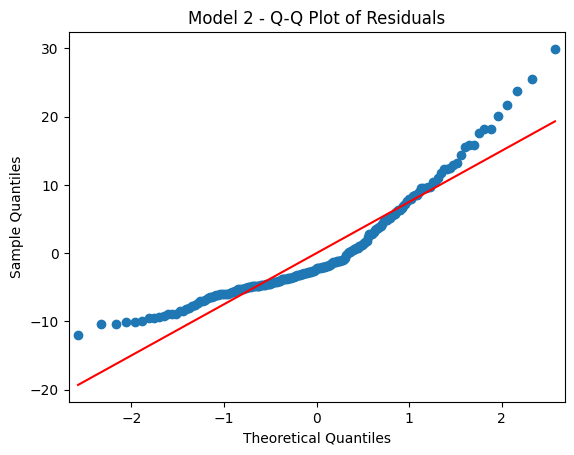

 Model 3 


<Figure size 600x600 with 0 Axes>

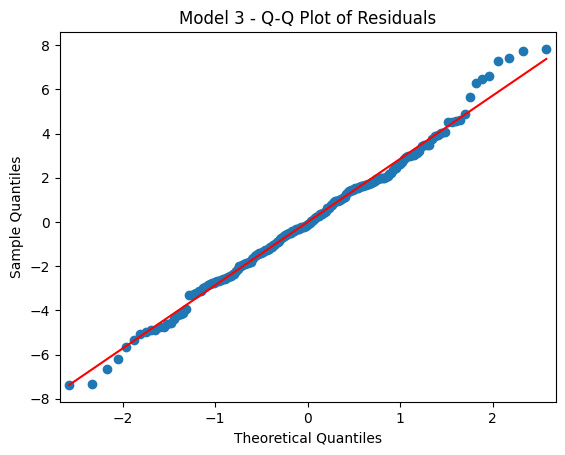

 Model 4 


<Figure size 600x600 with 0 Axes>

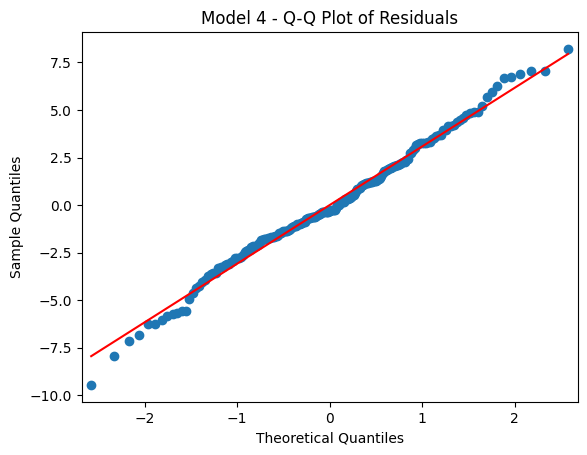

 Model 5 


<Figure size 600x600 with 0 Axes>

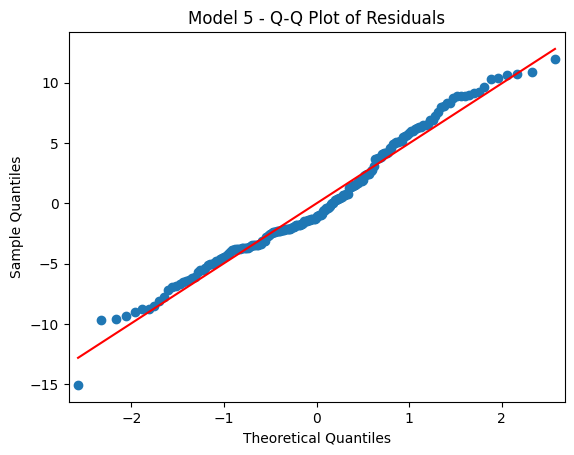

In [69]:
# 2.5 Residual Distribution Analysis (Q-Q Plot)
for i, model in enumerate(models):
    print(f" {model_names[i]} ")

    X_model = model(x1, x2)
    theta = inv(X_model.T @ X_model) @ X_model.T @ y

    # Calculate residuals
    predictions = X_model @ theta
    residuals = y - predictions

    # Create Q-Q plot
    plt.figure(figsize=(6, 6))
    sm.qqplot(residuals, line='s')
    plt.title(f'{model_names[i]} - Q-Q Plot of Residuals')
    plt.show()

### 2.6 Finding the best model

In [85]:
# To find model with the lowest AIC
best_model_by_aic = min(results, key=lambda model_name: results[model_name]['aic'] if isinstance(results[model_name], dict) and 'aic' in results[model_name] else float('inf'))
lowest_aic_value = results[best_model_by_aic]['aic']

# To find model with the lowest BIC
best_model_by_bic = min(results, key=lambda model_name: results[model_name]['bic'] if isinstance(results[model_name], dict) and 'bic' in results[model_name] else float('inf'))
lowest_bic_value = results[best_model_by_bic]['bic']

# Final selection based on agreement
if best_model_by_aic == best_model_by_bic:
    selected_best_model = best_model_by_aic
else:
    # Customize this based on preference
    selected_best_model = best_model_by_aic

# Print model selection results
print("Task 2.6: Model Selection")
print(f"Model with lowest AIC: {best_model_by_aic} (AIC = {lowest_aic_value:.2f})")
print(f"Model with lowest BIC: {best_model_by_bic} (BIC = {lowest_bic_value:.2f})")
print(f"Chosen 'best' model: {selected_best_model}")

# For task 2.7
results["best_model_name"] = selected_best_model

Task 2.6: Model Selection
Model with lowest AIC: Model 3 (AIC = 998.00)
Model with lowest BIC: Model 3 (BIC = 1014.49)
Chosen 'best' model: Model 3


### 2.7 Task
Split the input (sound) and output (MEG) dataset (𝐗 and 𝐲) into two parts: one part used to train the
model, the other used for testing (e.g. 70% for training, 30% for testing). For the selected ‘best’ model,
1) estimate model parameters use the training dataset; 2) compute the model’s output/prediction on
the testing data; and 3) also compute the 95% (model prediction) confidence intervals and plot them
(with error bars) together with the model prediction, as well as the testing data samples.

Task 2.7: Training and Testing Model 3 


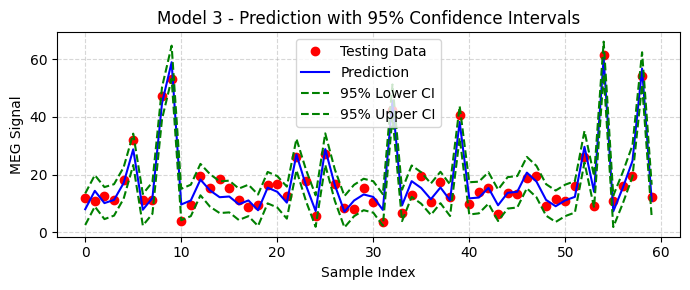

In [88]:
# Retrieving the selected best model name
selected_model_name = results["best_model_name"]
print(f"Task 2.7: Training and Testing {selected_model_name} ")

# Getting the function that is associated with the best model
models = [model_1, model_2, model_3, model_4, model_5]
model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5']
best_model_function = models[model_names.index(selected_model_name)]

# Generating the design matrix for the best model
best_design_matrix = best_model_function(x1, x2)

# Split data into training and testing sets 70/30 split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    best_design_matrix, y, test_size=0.3, random_state=42
)  #

# Train the model on training data
optimal_coefficients = inv(X_train.T @ X_train) @ X_train.T @ y_train

# Make predictions on the test set
test_predictions = X_test @ optimal_coefficients

# Calculate confidence intervals
test_residuals = y_test - test_predictions
residual_variance = np.var(test_residuals)
leverage_values = np.diag(X_test @ inv(X_train.T @ X_train) @ X_test.T)
prediction_std_error = np.sqrt(residual_variance * (1 + leverage_values))
margin_of_error = 1.96 * prediction_std_error  # 95% CI

confidence_lower = test_predictions - margin_of_error
confidence_upper = test_predictions + margin_of_error

# Plot results with confidence intervals
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 3))
plt.plot(y_test, 'ro', label='Testing Data')
plt.plot(test_predictions, 'b-', label='Prediction')
plt.plot(confidence_lower, 'g--', label='95% Lower CI')
plt.plot(confidence_upper, 'g--', label='95% Upper CI')
plt.xlabel('Sample Index')
plt.ylabel('MEG Signal')
plt.title(f'{selected_model_name} - Prediction with 95% Confidence Intervals')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Task 3: Approximate Bayesian Computation (ABC)

In [90]:
# 1. Identifying two Parameters with the Largest Absolute Values

# Retrieving the parameters from task 2
selected_model_name = results["best_model_name"]
theta_best = results[selected_model_name]['theta']  # Getting parameters of the best model


abs_theta = np.abs(theta_best.flatten())  # Absolute values of parameters
largest_param_indices = np.argsort(abs_theta)[-2:]  # Indices of 2 largest
largest_param_names = [f'theta_{i+1}' for i in largest_param_indices] # Names of the parameters

print(" Task 3: Approximate Bayesian Computation (ABC)")
print(f"Parameters with largest absolute values: {largest_param_names}")

 Task 3: Approximate Bayesian Computation (ABC)
Parameters with largest absolute values: ['theta_1', 'theta_5']


In [91]:
# 2.  Fix Other Parameters
#     ( Least Squares estimates from Task 2.1)
fixed_params = theta_best.flatten().copy()  # Create a copy to modify

In [93]:
# 3.  Define Prior Distributions,(Uniform priors centered around Least Squares estimates)
prior_ranges = {}
for i in largest_param_indices:
    param_value = theta_best[i]  # Least Squares estimate
    prior_ranges[i] = (param_value - np.abs(param_value) , param_value + np.abs(param_value) )  # Example: +/- 10% of the estimate
    print(f"Prior range for theta_{i+1}: {prior_ranges[i]}")

Prior range for theta_1: (np.float64(0.0), np.float64(17.1043226950703))
Prior range for theta_5: (np.float64(0.0), np.float64(20.34739217048436))


Number of Accepted Parameters: 267


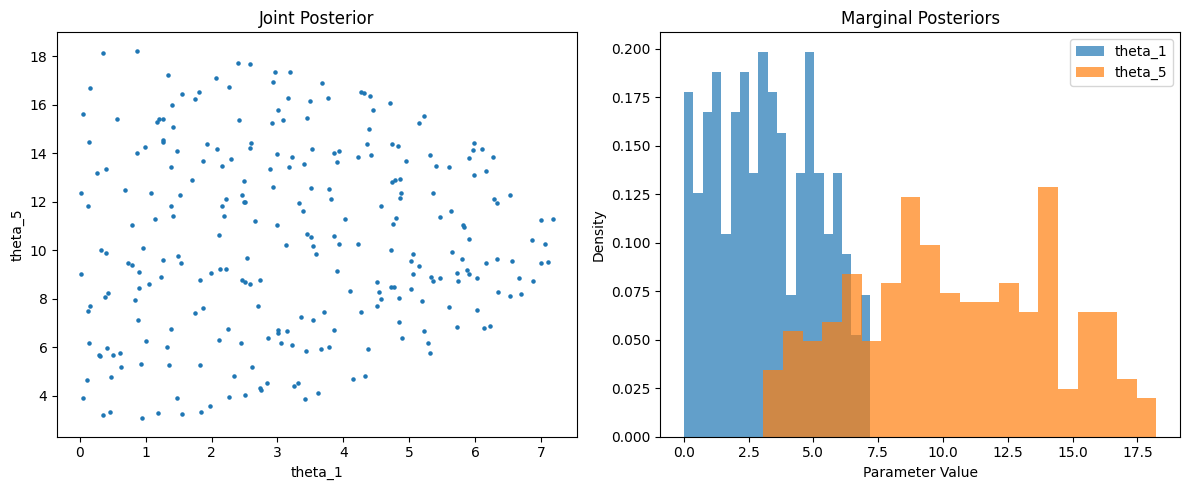

In [110]:
# 4.  Rejection ABC
def distance_metric(data1, data2):
    # A simple distance metric (e.g., mean squared error)
    return np.mean((data1 - data2) ** 2)

epsilon = 250  # Threshold for acceptance (YOU need to tune this)
n_samples = 1000  # Number of ABC samples
accepted_params = []

for _ in range(n_samples):
    # 4.1 Sample from Priors
    sampled_params = fixed_params.copy()
    for i in prior_ranges:
        sampled_params[i] = np.random.uniform(prior_ranges[i][0], prior_ranges[i][1])

    # 4.2 Generate Simulated Data
    X_simulated = best_model_function(x1, x2)  # Use the 'best_model_function' instead of 'theta_best'
    y_simulated = X_simulated @ sampled_params.reshape(-1, 1)

    # 4.3 Compare Simulated and Actual Data
    distance = distance_metric(y_simulated, y)
    if distance < epsilon:
        accepted_params.append(sampled_params)

accepted_params = np.array(accepted_params)

print(f"Number of Accepted Parameters: {len(accepted_params)}")

# 5.  Plot Posterior Distributions
if accepted_params.size > 0:
    plt.figure(figsize=(12, 5))

    # 5.1 Joint Posterior
    plt.subplot(1, 2, 1)
    plt.scatter(accepted_params[:, largest_param_indices[0]], accepted_params[:, largest_param_indices[1]], s=5)
    plt.xlabel(largest_param_names[0])
    plt.ylabel(largest_param_names[1])
    plt.title("Joint Posterior")

    # 5.2 Marginal Posteriors
    plt.subplot(1, 2, 2)
    plt.hist(accepted_params[:, largest_param_indices[0]], bins=20, density=True, alpha=0.7, label=largest_param_names[0])
    plt.hist(accepted_params[:, largest_param_indices[1]], bins=20, density=True, alpha=0.7, label=largest_param_names[1])
    plt.xlabel("Parameter Value")
    plt.ylabel("Density")
    plt.title("Marginal Posteriors")
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No parameters accepted. Adjust epsilon or prior ranges.")